# Model

In [1]:
from topological_insulator import Problem

structure_path = "../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name)

## Eigenvalues

In [2]:
import numpy as np

def _set_eigenvalues(problem:Problem, t1, t2, delta, U):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        parser["chadi_soc"][label_i]["Delta_pp"] = t2
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.5 * t1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = np.abs(t1)/2
                parser["nn_hopping"][label_j]["t_pp_pi"] = t1
                parser["nn_hopping"][label_j]["delta_heavy"] = delta
                parser["nn_hopping"][label_j]["delta_light"] = delta
            except:
                pass
        print(parser)

In [3]:
t1 = -1
t2 = 5.*t1 # Large SO splitting of j states
U = 0
delta = 0

_set_eigenvalues(problem, t1, t2, delta, U)

{'onsite_energy': {'A': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'B': {'t_ss_sigma': -0.5, 't_sp_sigma': 0, 't_pp_sigma': np.float64(0.5), 't_pp_pi': -1, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'A': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': -5.0}}, 'interaction': {'A': {'U_s': 0, 'U_p': 0, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': 0, 'n_px_down': 0, 'n_py_up': 0, 'n_py_down': 0, 'n_pz_up': 0, 'n_pz_down': 0}}}
{'onsite_energy': {'B': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'A': {'t_ss_sigma': -0.5, 't_sp_sigma': 0, 't_pp_sigma': np.float64(0.5), 't_pp_pi': -1, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'B': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'B': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': -5.0}}, 'interaction': {'B': {'U_s': 0, 'U_p': 0, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': 0, 'n_px_down': 0, 'n_py_up': 0, 'n_py_down': 0, 'n_pz_up': 0, 'n_pz_down': 0}}}


In [4]:
location = "edge"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 500, # reciprocal space discretization
    location = location,
    BZ = "reduced",
    dangling_bonds = False
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [5]:
g = problem.geometry
tb = problem.hamiltonian["edge"]["tight_binding"]

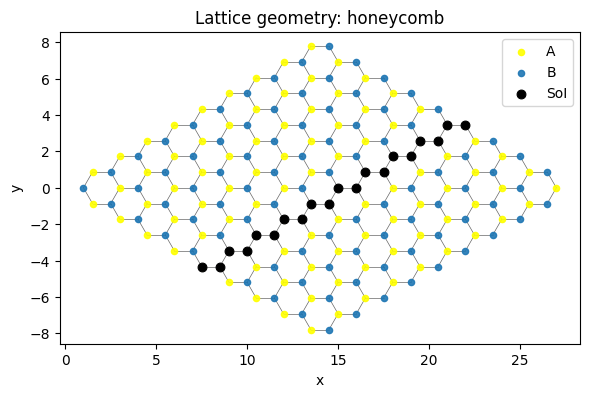

In [6]:
g.plot_lattice(sites_of_interest=tb.sublattice_idxs)

In [7]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


## Band Inversion

In [26]:
k_target = 0.0
edge_sites = [0, -1]
edge_bands = tb.get_edge_bands(g, edge_sites=edge_sites, k_target=k_target, threshold=0.1)
edge_bands

[118, 119, 120, 121]

# LDOS for edge site i = 0 (same for i = 19)

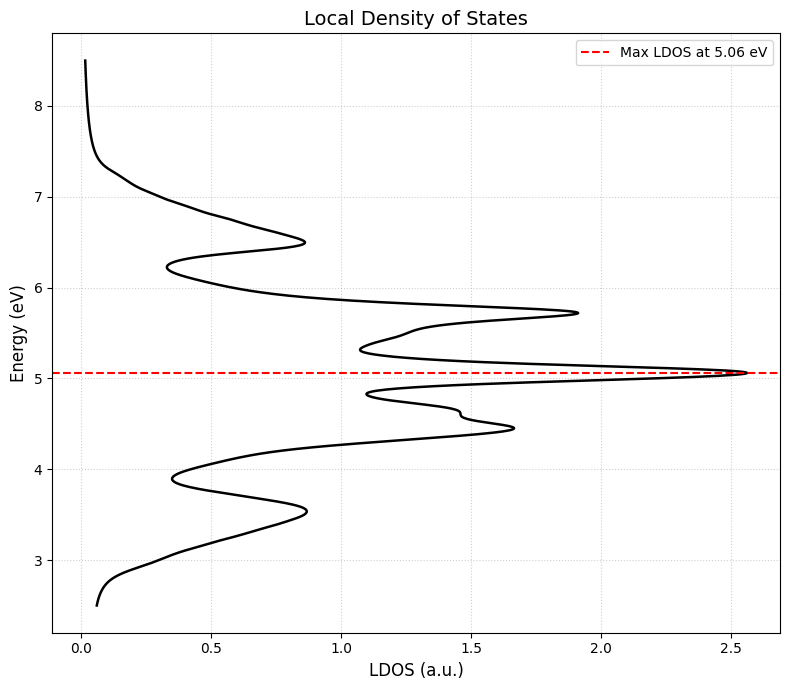

In [33]:
invariants = problem.hamiltonian[location]["topological_invariants"]
LDOS, E = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8.5, 
    E_min = 2.5,
    eta = 0.1
)

invariants.plot_density_of_states(LDOS, E)

## $j_{\frac{3}{2}}$ Bands

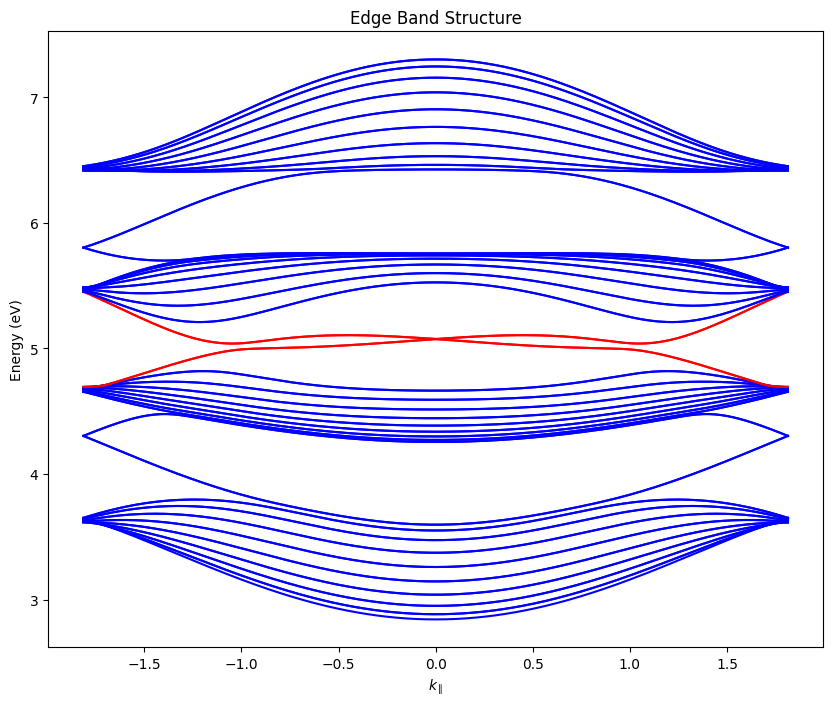

In [24]:
N_projections = len(tb.coupled_states)
N_sites = len(tb.sublattice_idxs)
N_bands = N_sites * N_projections
bands = [i for i in range(N_bands)]

j_3_2 = [i for i in range(81, 160)]
j_1_2 = [i for i in range(0, 40)]
s_orbitals = [i for i in range(41, 80)]
tb.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

## Atomic Wavefunction Contribution at k = 0.0

Total norm: 1.000000


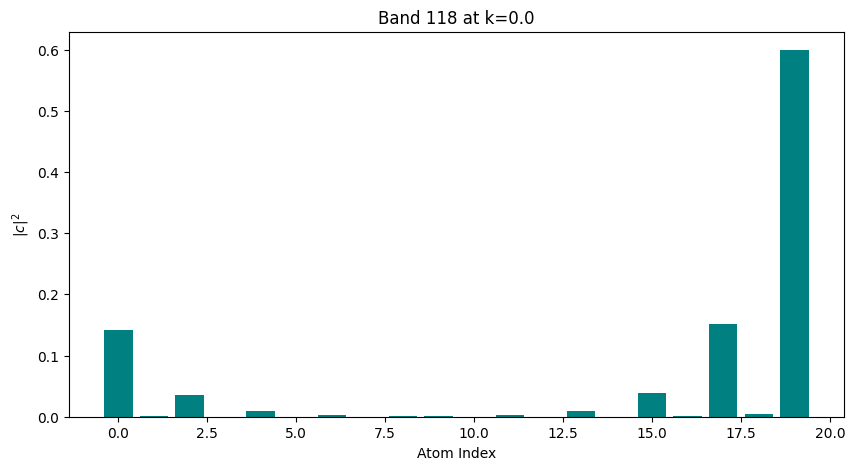

Total norm: 1.000000


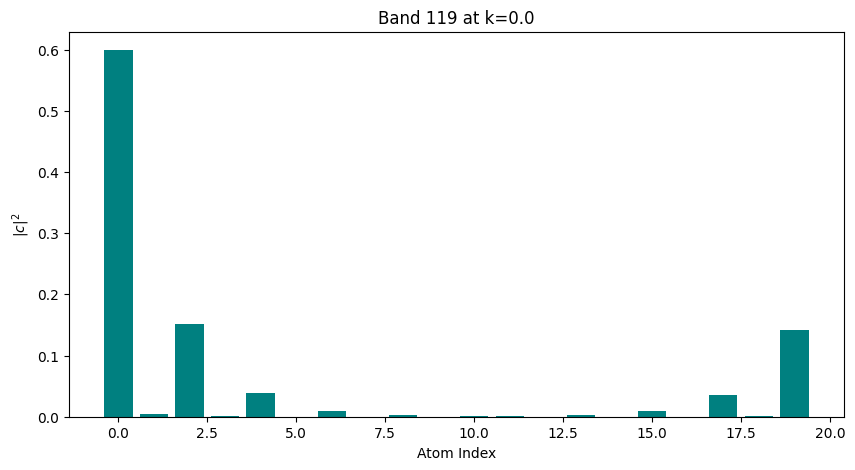

Total norm: 1.000000


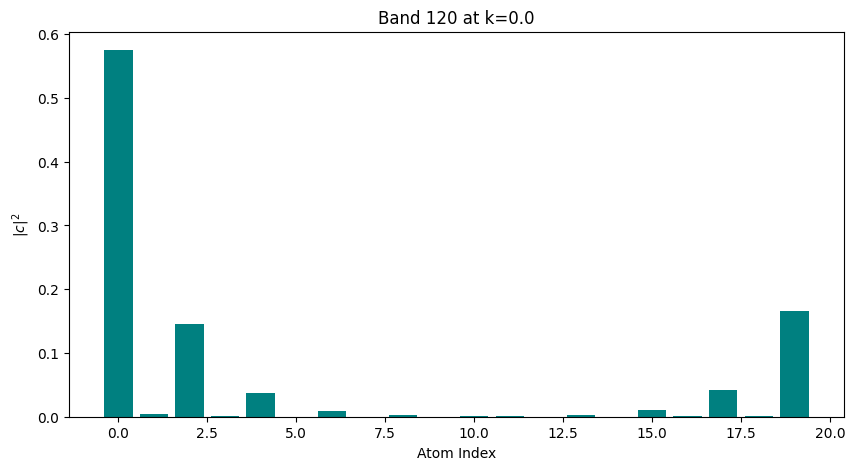

Total norm: 1.000000


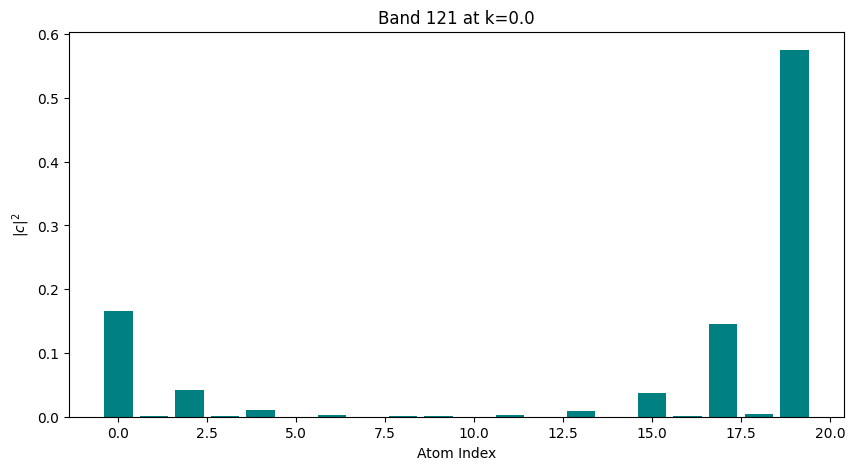

In [34]:
N_projections = len(tb.coupled_states)
N_sites = len(tb.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"Total norm: {total_norm:.6f}")
    n_atoms = len(tb.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()